In [22]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
import colorir as cl
import numpy as np
from pathlib import Path
import analyses.calculate_adh as adh

In [2]:
run = "../runs/evo/avg-gamma4/s5000000/"
dfs = {}
for file in Path(run + "cells").iterdir():
    data = pl.read_parquet(file)
    time = int(file.name.rstrip(".parquet"))
    data = data.with_columns(time=time)
    dfs[time] = data

In [40]:
celldf = pl.concat(dfs.values())

In [3]:
time_it = sorted(dfs.keys())

In [30]:
ancdf = dfs[0].select(["index", "ancestor"])
for i, time in enumerate(time_it[1:]):
    ancs = dfs[time].select("index", "ancestor")
    ancdf = ancs.join(ancdf.select(pl.exclude("ancestor")), left_on="ancestor", right_on="index", how="left", coalesce=False).rename({"index_right": str(time_it[i])})
ancdf_pivoted = ancdf.select(pl.exclude("ancestor")).rename({"index": f"{time_it[i + 1]}"})

In [33]:
ancdf = ancdf_pivoted.with_columns(lineage=np.arange(ancdf_pivoted.height)).unpivot(index="lineage", value_name="index", variable_name="time").with_columns(pl.col("time").cast(int).alias("time"))

In [35]:
palette = cl.StackPalette.load("spectral").resize(ancdf_pivoted.height)

/tmp/ipykernel_2571/3225699822.py:1: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



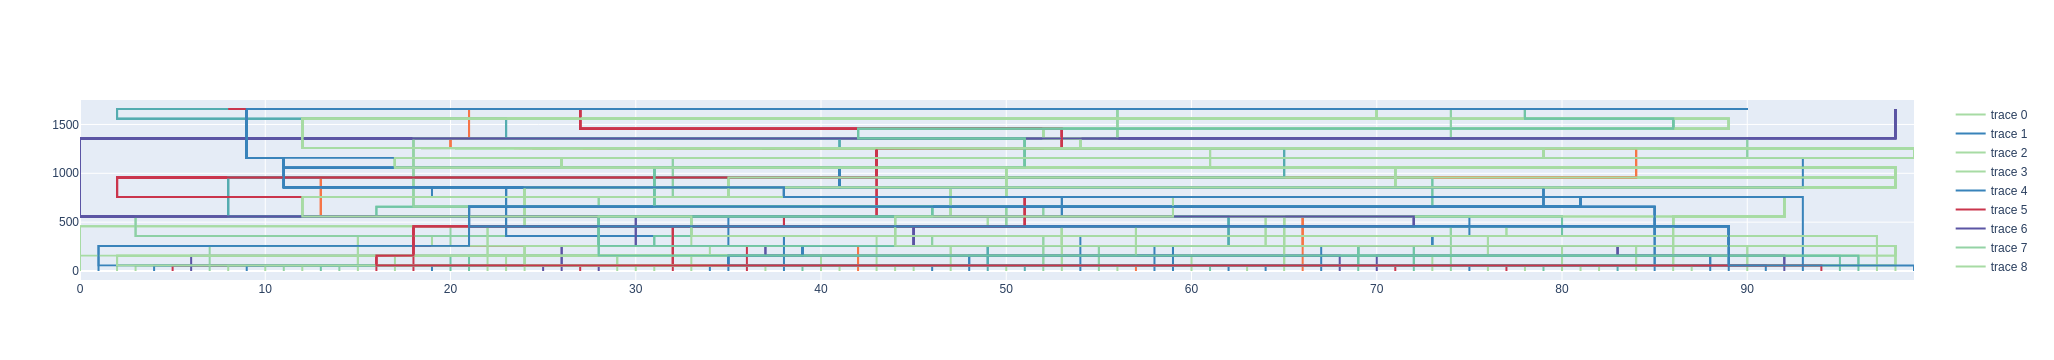

In [36]:
fig = go.Figure()
for col in ancdf_pivoted.transpose().iter_columns():
    color = palette[col[-1]]
    fig.add_trace(go.Scatter(
        x=col,
        y=list(range(0, len(col))),
        marker_color=color,
        line_color=color
    ))
fig

In [94]:
fig = go.Figure()
contact_table = adh.contact_energy_table(np.ones(8))
for lin, group in ancdf.group_by("lineage"):
    lindf = group.join(celldf, left_on=["time", "index"], right_on=["time", "index"]).unique(["ligands", "receptors"]).sort("time")
    adhdf = lindf.with_columns(gamma=pl.Series([adh.calculate_gamma(28, 48, adh.cell_contact_energy(lig, rec, lig, rec, contact_table)) for lig, rec in zip(lindf["ligands"], lindf["receptors"])]))
    fig.add_trace(go.Scatter(
        x=adhdf["time"],
        y=adhdf["gamma"],
        mode="markers+lines",
        marker_color=palette[lin[0]],
        line_color=palette[lin[0]],
        visible="legendonly"
    ))

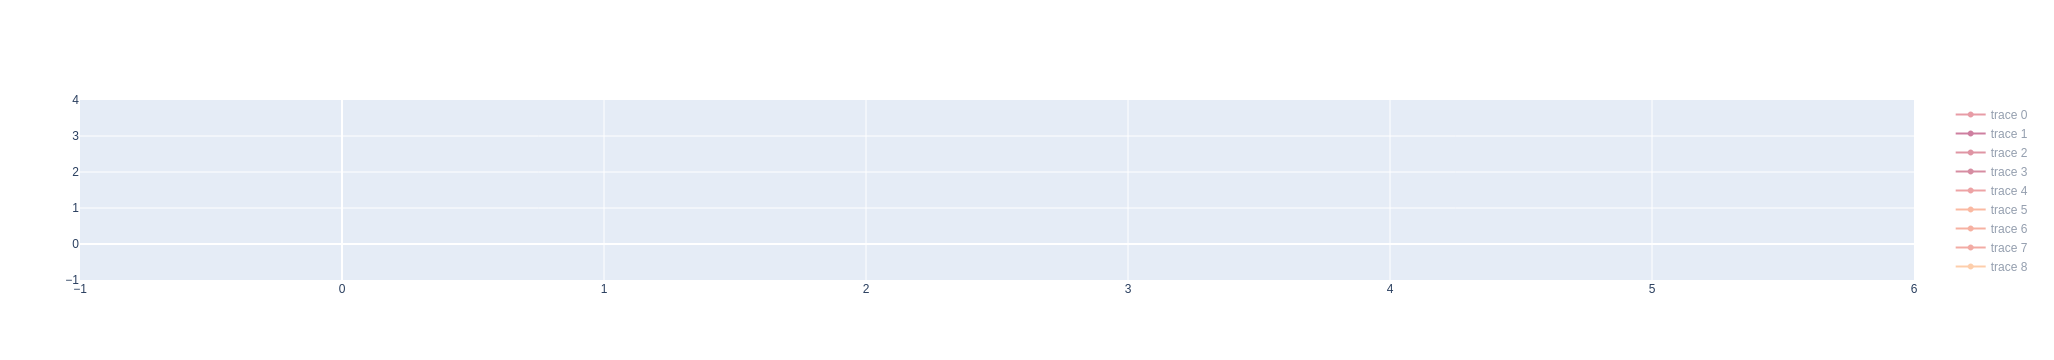

In [96]:
fig.update_layout(width=500)